# E-commerce Behavioral Experiments
## A/B Testing on the Olist Marketplace Dataset

---

# Introduction

Understanding customer behavior is critical for optimizing e-commerce operations. Businesses frequently conduct A/B tests to evaluate how operational or marketing changes influence customer behavior.

In this notebook, we analyze several behavioral and operational factors in the Olist e-commerce dataset using statistical hypothesis testing. The aim is to determine whether specific conditions create statistically significant differences in customer satisfaction, purchasing behavior, and pricing outcomes.

The experiments focus on the following business questions:

- Does fast delivery improve customer satisfaction?
- Do installment payments increase order value?
- Does late delivery harm customer satisfaction?
- Does free shipping increase order revenue?
- Do higher shipping costs impact customer reviews?
- Do multi-item orders receive higher discounts?
- Do repeat customers behave differently from new customers?

---

# Methodology

This analysis uses **A/B testing** to compare two independent groups and evaluate whether their observed differences are statistically significant.

All hypothesis tests are conducted as **two-sided tests**, meaning that we test for any statistically significant difference between groups rather than testing for a specific direction of change.

---

## Hypothesis Structure

For all experiments, the hypotheses are defined as follows:

H₀: μ₁ = μ₂  

H₁: μ₁ ≠ μ₂  

Where:

- **H₀ (Null Hypothesis):** There is no statistically significant difference between the two groups.
- **H₁ (Alternative Hypothesis):** There is a statistically significant difference between the two groups.

---

## Significance Level

The significance level used in this analysis is:

α = 0.05

Decision rule:

- If **p-value < 0.05**, we reject the null hypothesis.
- If **p-value ≥ 0.05**, we fail to reject the null hypothesis.

---

## Test Selection

Before selecting the appropriate statistical test, we examine whether the normality assumption holds using the **Shapiro-Wilk test**.

Depending on the distribution of the data, different tests are applied.

| Condition | Test Used |
|---|---|
| Data follows normal distribution | Independent Samples T-Test |
| Data does not follow normal distribution | Mann–Whitney U Test |

Since many e-commerce metrics such as revenue and order value are typically skewed, **non-parametric tests are often preferred**.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql

import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal, normaltest
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [117]:
## SQL Connection
conn = pymysql.connect(database = "olist", user = "root", password = "160510", local_infile=True)
cursor = conn.cursor()

In [225]:
df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)
df_all.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_26136\383586695.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


In [226]:
def check_df(dataframe, head=5):
    print("############## HEAD ################")
    print(dataframe.head(head))
    print("############## TAIL ################")
    print(dataframe.tail(head))
    print("############## INFO ################")
    print(dataframe.info())
    print("############## SHAPE ################")
    print(dataframe.shape)
    print("############## NA ################")
    print(dataframe.isnull().sum())
    print("############## DESCRIBE ################")
    print(dataframe.describe().T)

In [227]:
check_df(df_all)

############## HEAD ################
                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1  00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
2  000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
3  00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
4  00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   

                 customer_unique_id order_status         purchase_ts  \
0  871766c5855e863f6eccc05f988b23cb    delivered 2017-09-13 08:59:02   
1  eb28e67c4c0b83846050ddfb8a35d051    delivered 2017-04-26 10:53:06   
2  3818d81c6709e39d06b2738a8d3a2474    delivered 2018-01-14 14:33:31   
3  af861d436cfc08b2c2ddefd0ba074622    delivered 2018-08-08 10:00:35   
4  64b576fb70d441e8f1b2d7d446e483c5    delivered 2017-02-04 13:57:51   

           approved_ts           carrier_ts         delivered_ts  \
0  2017-09-13 09:45:35 

In [228]:
# Editing the data type of the date columns:
date_cols = ["purchase_ts","approved_ts","carrier_ts","delivered_ts","review_creation_date"]
for c in date_cols:
    if c in df_all.columns:
        df_all[c] = pd.to_datetime(df_all[c], errors="coerce")

In [229]:
cat_cols = ["main_category_by_item","main_category_by_revenue","order_type","all_categories"]
for c in cat_cols:
    if c in df_all.columns:
        df_all[c] = df_all[c].astype(str).str.replace(r"[\r\n\t]", "", regex=True).str.strip()

In [230]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP


In [231]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96464 non-null  datetime64[ns]
 6   carrier_ts                96476 non-null  datetime64[ns]
 7   delivered_ts              96470 non-null  datetime64[ns]
 8   est_delivery_ts           96478 non-null  datetime64[ns]
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight     

In [232]:
df_all.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
order_status                   0
purchase_ts                    0
approved_ts                   14
carrier_ts                     2
delivered_ts                   8
est_delivery_ts                0
days_to_deliver                8
is_late                        0
total_price                    0
total_freight                  0
total_revenue                  0
item_count                     0
total_payment                  1
payment_count                  1
max_installments               1
payment_minus_revenue          1
review_score                1107
review_comment_title        1107
review_comment_message      1107
review_creation_date        1108
main_category_by_item          0
main_category_by_revenue       0
category_count                 0
order_type                     0
all_categories                 0
customer_city                  0
customer_state                 0
dtype: int

In [233]:
df_all = df_all.dropna(subset=["days_to_deliver","review_score",
                               "max_installments"]).copy()

df_all.isnull().sum()

order_id                     0
customer_id                  0
customer_unique_id           0
order_status                 0
purchase_ts                  0
approved_ts                 14
carrier_ts                   1
delivered_ts                 0
est_delivery_ts              0
days_to_deliver              0
is_late                      0
total_price                  0
total_freight                0
total_revenue                0
item_count                   0
total_payment                0
payment_count                0
max_installments             0
payment_minus_revenue        0
review_score                 0
review_comment_title         0
review_comment_message       0
review_creation_date         1
main_category_by_item        0
main_category_by_revenue     0
category_count               0
order_type                   0
all_categories               0
customer_city                0
customer_state               0
dtype: int64

In [234]:
def ab_testing(test, control, reason = "Fast Delivery", conclusion = "Review Score", proportions_test=False):
    
    test = pd.Series(test).dropna()
    control = pd.Series(control).dropna()
    
    # Means
    test_mean = test.mean()
    control_mean = control.mean()

    # Uplift (avoid early rounding)
    uplift = (test_mean - control_mean) / control_mean if control_mean != 0 else np.nan

    n_test, n_control = len(test), len(control)

    if proportions_test:
        if not set(test.unique()).issubset({0,1}) or not set(control.unique()).issubset({0,1}):
            raise ValueError("For `proportions_ztest=True`, `test/control` must be 0-1 (binary).")
        test_name = "proportions_test"
        g1_succ_count = int(test.sum())
        g2_succ_count = int(control.sum())

        test_stat, pvalue = proportions_ztest(count=[g1_succ_count, g2_succ_count],
                                      nobs=[test.shape[0],
                                            control.shape[0]])

        results = pd.DataFrame({
                        "Experiment": [reason],
                        "Metric": [conclusion],
                        "Control Mean": [round(control_mean, 4)],
                        "Test Mean": [round(test_mean, 4)],
                        "n_control": [n_control],
                        "n_test": [n_test],
                        "Uplift (%)": [round(uplift * 100, 2)],
                        "Test": [test_name],
                        "p-value": [pvalue],
                        "Result": ["Significant" if pvalue < 0.05 else "Non significant"]
                    })
        return results

    else:
        if len(test) > 5000 or len(control) > 5000:
            pvalue_g1 = normaltest(test)[1]
            pvalue_g2 = normaltest(control)[1]
        else:
            pvalue_g1 = shapiro(test)[1]
            pvalue_g2 = shapiro(control)[1]
        
        if (pvalue_g1 < 0.05) or (pvalue_g2 < 0.05):
            test_name = "Mann–Whitney U"
            test_stat, pvalue = mannwhitneyu(test,
                                             control,
                                            alternative="two-sided")
            results = pd.DataFrame({
                    "Experiment": [reason],
                    "Metric": [conclusion],
                    "Control Mean": [round(control_mean, 4)],
                    "Test Mean": [round(test_mean, 4)],
                    "n_control": [n_control],
                    "n_test": [n_test],
                    "Uplift (%)": [round(uplift * 100, 2)],
                    "Test": [test_name],
                    "p-value": [pvalue],
                    "Result": ["Significant" if pvalue < 0.05 else "Non significant"]
                })
    
            return results
    
        elif (pvalue_g1 >= 0.05) and (pvalue_g2 >= 0.05):
            test_stat, pvalue = levene(test,
                                       control)
            if pvalue < 0.05:
                # The situation where homogeneity of variance cannot be ensured.
                # Welch test
                test_name = "Welch"
                test_stat, pvalue = ttest_ind(test,
                                              control,
                                              equal_var=False,
                                             alternative = "two-sided")
                results = pd.DataFrame({
                                "Experiment": [reason],
                                "Metric": [conclusion],
                                "Control Mean": [round(control_mean, 4)],
                                "Test Mean": [round(test_mean, 4)],
                                "n_control": [n_control],
                                "n_test": [n_test],
                                "Uplift (%)": [round(uplift * 100, 2)],
                                "Test": [test_name],
                                "p-value": [pvalue],
                                "Result": ["Significant" if pvalue < 0.05 else "Non significant"]
                            })
                return results
                        
            else:
                # Ensuring homogeneity of variance
                # two-sample t-test (parametric test)
                test_name = "two-sample t-test"
                test_stat, pvalue = ttest_ind(test,
                                              control,
                                              equal_var=True,
                                             alternative = "two-sided")
    
                results = pd.DataFrame({
                                "Experiment": [reason],
                                "Metric": [conclusion],
                                "Control Mean": [round(control_mean, 4)],
                                "Test Mean": [round(test_mean, 4)],
                                "n_control": [n_control],
                                "n_test": [n_test],
                                "Uplift (%)": [round(uplift * 100, 2)],
                                "Test": [test_name],
                                "p-value": [pvalue],
                                "Result": ["Significant" if pvalue < 0.05 else "Non significant"]
                            })
                return results
                    

# Experiment 1 — Fast Delivery vs Slow Delivery

## Objective

This experiment investigates whether fast delivery has an impact on customer satisfaction.

Delivery performance is one of the most critical aspects of the e-commerce customer experience. Faster delivery may lead to higher review scores and improved customer satisfaction.

## Metric

Review Score

## Hypotheses

H₀: There is no statistically significant difference in review scores between fast delivery and slow delivery.

H₁: There is a statistically significant difference in review scores between fast delivery and slow delivery.

## Business Interpretation

If fast delivery significantly improves review scores, improving logistics performance may directly increase customer satisfaction and brand reputation.

---

In [236]:
median_delivery = df_all["days_to_deliver"].median()

df_all["delivery_group"] = df_all["days_to_deliver"].apply(
    lambda x: "fast" if x <= median_delivery else "slow"
)

In [237]:
df_all.groupby("delivery_group")["review_score"].mean()

delivery_group
fast   4.38276
slow   3.91595
Name: review_score, dtype: float64

In [238]:
df_all["delivery_group"].value_counts()

delivery_group
fast    49436
slow    45926
Name: count, dtype: int64

In [239]:
ab1_test = df_all.loc[df_all["delivery_group"] == "fast", "review_score"]
ab1_control = df_all.loc[df_all["delivery_group"] == "slow", "review_score"]

In [240]:
results_ab1 = ab_testing(ab1_test, ab1_control, reason = "Fast Delivery", conclusion = "Review Score", proportions_test=False)
results_ab1

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Fast Delivery,Review Score,3.91600,4.38280,45926,49436,11.92000,Mann–Whitney U,0.00000,Significant


# Experiment 2 — Installment Payment vs Single Payment

## Objective

This experiment evaluates whether installment payment options influence customer purchasing behavior.

Installment payments may encourage customers to purchase higher-value products by spreading the cost over multiple payments.

## Metric

Average Order Value (AOV)

## Hypotheses

H₀: There is no statistically significant difference in average order value between installment payments and single payments.

H₁: There is a statistically significant difference in average order value between installment payments and single payments.

## Business Interpretation

If installment payments increase order value, offering flexible payment options may be an effective strategy to increase revenue.


In [242]:
df_all["installment_group"] = df_all["max_installments"].apply(
    lambda x: "installment" if x > 1 else "single_payment"
)

In [243]:
df_all.groupby("installment_group").agg({"total_revenue":"mean"})

,total_revenue
installment_group,
installment,196.92479
single_payment,120.86134


In [244]:
ab2_test = df_all.loc[df_all["installment_group"] == "installment", "total_revenue"]
ab2_control = df_all.loc[df_all["installment_group"] == "single_payment", "total_revenue"]

In [245]:
results_ab2 = ab_testing(ab2_test, ab2_control, reason = "Installment Payment", conclusion = "Average Order Value", proportions_test=False)
results_ab2

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Installment Payment,Average Order Value,120.86130,196.92480,46723,48639,62.93000,Mann–Whitney U,0.00000,Significant


# Experiment 3 — Late Delivery vs On-Time Delivery

## Objective

This experiment examines whether delivery delays negatively affect customer satisfaction.

Late deliveries can damage the customer experience and potentially reduce trust in the platform.

## Metric

Review Score

## Hypotheses

H₀: There is no statistically significant difference in review scores between late deliveries and on-time deliveries.

H₁: There is a statistically significant difference in review scores between late deliveries and on-time deliveries.

## Business Interpretation

A statistically significant drop in review scores for late deliveries would indicate that logistics reliability is essential for maintaining customer satisfaction.

In [247]:
df_all.groupby("is_late")["review_score"].mean()

is_late
0   4.29606
1   2.56582
Name: review_score, dtype: float64

In [248]:
ab3_test = df_all.loc[df_all["is_late"] == 0, "review_score"]
ab3_control = df_all.loc[df_all["is_late"] == 1, "review_score"]

In [249]:
results_ab3 = ab_testing(ab3_test, ab3_control, reason = "Late Delivery", conclusion = "Review Score", proportions_test=False)
results_ab3

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Late Delivery,Review Score,2.56580,4.29610,7612,87750,67.43000,Mann–Whitney U,0.00000,Significant


# Experiment 4 — Free Shipping vs Paid Shipping

## Objective

Free shipping is one of the most widely used promotional strategies in e-commerce. This experiment evaluates whether orders with free shipping generate higher revenue.

## Metric

Order Revenue

## Hypotheses

H₀: There is no statistically significant difference in revenue between free shipping orders and paid shipping orders.

H₁: There is a statistically significant difference in revenue between free shipping orders and paid shipping orders.

## Business Interpretation

If free shipping significantly increases revenue, the strategy may be beneficial despite the additional shipping cost.

In [251]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,delivery_group,installment_group
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ,fast,installment
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP,slow,installment
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG,fast,installment
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP,fast,installment
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP,slow,installment


In [252]:
df_all["freight_ratio"] = df_all["total_freight"] / df_all["total_price"]
df_all["freight_ratio"].describe()

count   95362.00000
mean        0.30837
std         0.31177
min         0.00000
25%         0.13201
50%         0.22437
75%         0.38037
max        21.44706
Name: freight_ratio, dtype: float64

In [253]:
median_freight_ratio = df_all["freight_ratio"].median()

df_all["freight_group"] = df_all["freight_ratio"].apply(
    lambda x: "low" if x <= median_freight_ratio else "high"
)

In [254]:
df_all.groupby("freight_group")["total_revenue"].mean()

freight_group
high    88.72222
low    230.53566
Name: total_revenue, dtype: float64

In [255]:
ab4_test = df_all.loc[df_all["freight_group"] == "low", "total_revenue"]
ab4_control = df_all.loc[df_all["freight_group"] == "high", "total_revenue"]

In [256]:
results_ab4 = ab_testing(ab4_test, ab4_control, reason = "Low Freight Cost", conclusion = "Average Order Value", proportions_test=False)
results_ab4

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Low Freight Cost,Average Order Value,88.72220,230.53570,47662,47700,159.84000,Mann–Whitney U,0.00000,Significant


# Experiment 5 — Shipping Cost vs Customer Satisfaction

## Objective

Shipping costs are a critical component of the customer experience. Higher shipping costs may negatively influence customer satisfaction.

This experiment evaluates whether orders with higher shipping costs receive different review scores.

## Metric

Review Score

## Hypotheses

H₀: There is no statistically significant difference in review scores between orders with low shipping costs and high shipping costs.

H₁: There is a statistically significant difference in review scores between orders with low shipping costs and high shipping costs.

## Business Interpretation

If higher shipping costs reduce review scores, optimizing shipping cost strategies could improve overall customer satisfaction.


In [286]:
ab5_test = df_all.loc[df_all["freight_group"] == "low", "review_score"]
ab5_control = df_all.loc[df_all["freight_group"] == "high", "review_score"]

In [288]:
results_ab5 = ab_testing(ab5_test, ab5_control, reason = "Low Freight Cost", conclusion = "Review Score", proportions_test=False)
results_ab5

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Low Freight Cost,Review Score,4.13090,4.18490,47662,47700,1.31000,Mann–Whitney U,0.00000,Significant


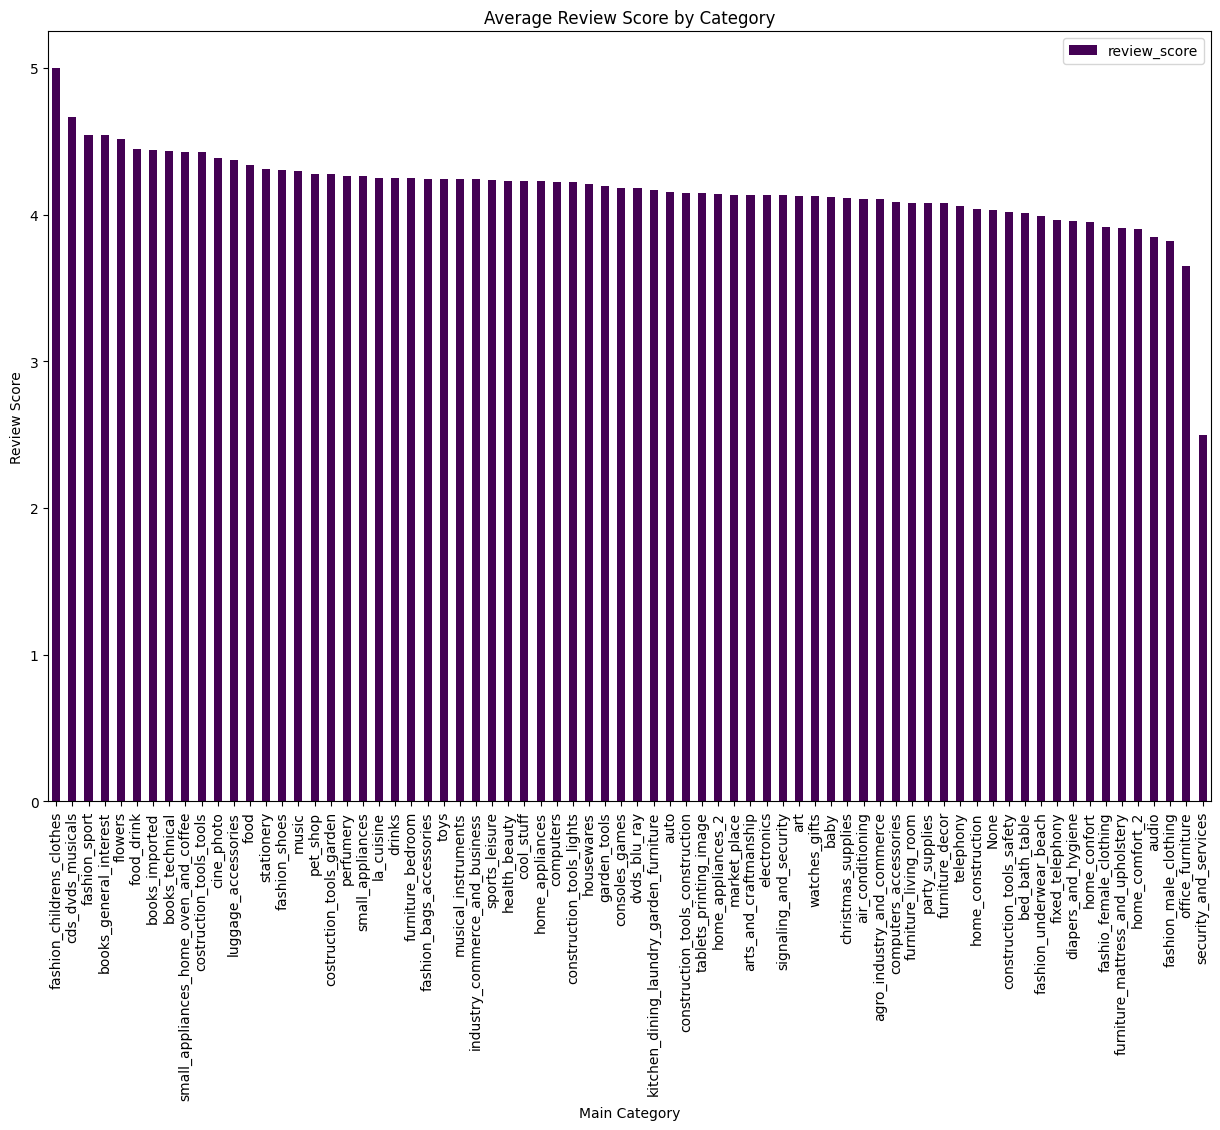

In [290]:
plot_df = (
    df_all
    .groupby("main_category_by_revenue")
    .agg({"review_score": "mean"})
    .sort_values(by="review_score", ascending=False)
)

plot_df.plot(
    kind="bar",
    figsize=(15,10),
    colormap="viridis"
)

plt.title("Average Review Score by Category")
plt.ylabel("Review Score")
plt.xlabel("Main Category")
plt.xticks(rotation=90)
plt.show()

# Experiment 6 — Multi-item Orders vs Single-item Orders

## Objective

Customers who purchase multiple items in a single order may receive higher discounts as part of bundle or promotional pricing strategies.

This experiment analyzes whether multi-item orders have higher discount ratios.

## Metric

Discount Ratio

Discount ratio is calculated as:

discount_ratio = 1 - (total_payment / total_revenue)

## Hypotheses

H₀: There is no statistically significant difference in discount ratios between multi-item orders and single-item orders.

H₁: There is a statistically significant difference in discount ratios between multi-item orders and single-item orders.

## Business Interpretation

If multi-item orders receive higher discounts, it may indicate that promotional strategies encourage customers to increase basket size.

In [292]:
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,delivery_group,installment_group,freight_ratio,freight_group
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ,fast,installment,0.22564,high
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP,slow,installment,0.08308,low
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG,fast,installment,0.08980,low
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15,perfumery,perfumery,1,Single,perfumery,atibaia,SP,fast,installment,0.98460,high
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP,slow,installment,0.09075,low


In [294]:
df_all["category_count"].value_counts()

category_count
1    94597
2      748
3       17
Name: count, dtype: int64

In [297]:
df_all["discount_ratio"] = 1 - (df_all["total_payment"] / df_all["total_revenue"])
df_all["discount_ratio"].describe()

count   95362.00000
mean        0.01613
std         0.10602
min        -0.41336
25%         0.00000
50%         0.00000
75%         0.00000
max         0.99997
Name: discount_ratio, dtype: float64

In [299]:
df_all.groupby("order_type").agg({"discount_ratio":["mean", "median"]})

discount_ratio        
                     mean  median
order_type                       
Multi             0.02290 0.00000
Single            0.01607 0.00000

In [301]:
df_all.isnull().sum()

order_id                     0
customer_id                  0
customer_unique_id           0
order_status                 0
purchase_ts                  0
approved_ts                 14
carrier_ts                   1
delivered_ts                 0
est_delivery_ts              0
days_to_deliver              0
is_late                      0
total_price                  0
total_freight                0
total_revenue                0
item_count                   0
total_payment                0
payment_count                0
max_installments             0
payment_minus_revenue        0
review_score                 0
review_comment_title         0
review_comment_message       0
review_creation_date         1
main_category_by_item        0
main_category_by_revenue     0
category_count               0
order_type                   0
all_categories               0
customer_city                0
customer_state               0
delivery_group               0
installment_group            0
freight_

In [311]:
ab6_test = df_all.loc[df_all["order_type"] == "Multi", "discount_ratio"]
ab6_control = df_all.loc[df_all["order_type"] == "Single", "discount_ratio"]

In [315]:
results_ab6 = ab_testing(ab6_test, ab6_control, reason = "Multi Order", conclusion = "Discount Ratio", proportions_test=False)
results_ab6

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Multi Order,Discount Ratio,0.01610,0.02290,94597,765,42.49000,Mann–Whitney U,0.00077,Significant


# Experiment 7 — Repeat Customers vs New Customers

## Objective

Repeat customers often exhibit different purchasing behavior compared to new customers.

This experiment investigates whether repeat customers generate higher or lower average order values.

## Metric

Average Order Value

## Hypotheses

H₀: There is no statistically significant difference in average order value between repeat customers and new customers.

H₁: There is a statistically significant difference in average order value between repeat customers and new customers.

## Business Interpretation

Repeat customers may place smaller but more frequent orders, while new customers may place larger initial purchases.

Understanding these patterns can help businesses optimize customer retention strategies.

In [318]:
# Let's find out how many orders each customer placed.

customer_orders = (
    df_all.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

customer_orders.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [320]:
# Repeat Customer Flag
customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] > 1,
    "repeat_customer",
    "new_customer"
)

customer_orders.head()

,customer_unique_id,order_count,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,new_customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,new_customer
2,0000f46a3911fa3c0805444483337064,1,new_customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,new_customer
4,0004aac84e0df4da2b147fca70cf8255,1,new_customer


In [322]:
df_all = df_all.merge(customer_orders[["customer_unique_id","customer_type"]],
                      on="customer_unique_id",
                      how="left")

In [324]:
df_all.groupby("customer_type").agg({"total_revenue": ["mean","median"]})

total_revenue          
                         mean    median
customer_type                          
new_customer        160.30868 105.37000
repeat_customer     147.95010 101.31000

In [326]:
ab7_test = df_all.loc[df_all["customer_type"] == "repeat_customer", "total_revenue"]
ab7_control = df_all.loc[df_all["customer_type"] == "new_customer", "total_revenue"]

In [328]:
results_ab7 = ab_testing(ab7_test, ab7_control, reason = "Repeat Customer", conclusion = "Average Order Value", proportions_test=False)
results_ab7

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Repeat Customer,Average Order Value,160.30870,147.95010,90335,5027,-7.71000,Mann–Whitney U,0.00185,Significant


## 8. Late Delivery vs On-Time Delivery — Repeat Purchase

### Hypothesis

H0: There is no statistically significant difference in repeat purchase rates between late deliveries and on-time deliveries.

H1: There is a statistically significant difference in repeat purchase rates between late deliveries and on-time deliveries.

In [330]:
customer_orders.head()

,customer_unique_id,order_count,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,new_customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,new_customer
2,0000f46a3911fa3c0805444483337064,1,new_customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,new_customer
4,0004aac84e0df4da2b147fca70cf8255,1,new_customer


In [336]:
customer_orders["is_repeat_customer"] = (
    customer_orders["order_count"] > 1
).astype(int)

In [338]:
# Each customer's first order:
first_orders = (
    df_all.sort_values("purchase_ts")
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

In [339]:
first_orders.head()

,customer_unique_id,order_id,customer_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,delivery_group,installment_group,freight_ratio,freight_group,discount_ratio,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,6.00000,0,129.90000,12.00000,141.90000,1,141.90000,1.00000,8.00000,0.00000,5.00000,Super Recomendo,"Adorei a cortina, ficou linda na minha sala, e...",2018-05-17,bed_bath_table,bed_bath_table,1,Single,bed_bath_table,cajamar,SP,fast,installment,0.09238,low,0.00000,new_customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,3.00000,0,18.90000,8.29000,27.19000,1,27.19000,1.00000,1.00000,0.00000,4.00000,,,2018-05-11,health_beauty,health_beauty,1,Single,health_beauty,osasco,SP,fast,single_payment,0.43862,high,0.00000,new_customer
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,26.00000,0,69.00000,17.22000,86.22000,1,86.22000,1.00000,8.00000,0.00000,3.00000,,,2017-04-06,stationery,stationery,1,Single,stationery,sao jose,SC,slow,installment,0.24957,high,0.00000,new_customer
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,20.00000,0,25.99000,17.63000,43.62000,1,43.62000,1.00000,4.00000,0.00000,4.00000,,Bom vendedor,2017-11-02,telephony,telephony,1,Single,telephony,belem,PA,slow,installment,0.67834,high,0.00000,new_customer
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,13.00000,0,180.00000,16.89000,196.89000,1,196.89000,1.00000,6.00000,0.00000,5.00000,,,2017-11-28,telephony,telephony,1,Single,telephony,sorocaba,SP,slow,installment,0.09383,low,0.00000,new_customer


In [342]:
first_orders = first_orders.merge(
    customer_orders[["customer_unique_id","is_repeat_customer"]],
    on="customer_unique_id",
    how="left"
)

In [344]:
# Repeat Rate
first_orders.groupby("is_late").agg({"is_repeat_customer":"mean"})

,is_repeat_customer
is_late,
0,0.02622
1,0.01948


* On-time delivery, 2.5% repeat order rate.
* Late delivery 1.9% repeat order

In [347]:
ab8_test = first_orders.loc[first_orders["is_late"] == 1, "is_repeat_customer"]
ab8_control = first_orders.loc[first_orders["is_late"] == 0, "is_repeat_customer"]

In [349]:
# Proportion Test (Binary metric)

results_ab8 = ab_testing(ab8_test, ab8_control, reason = "Late Delivery", conclusion = "Repeat Purchase", proportions_test=True)
results_ab8

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Late Delivery,Repeat Purchase,0.02620,0.01950,85274,7442,-25.69000,proportions_test,0.00043,Significant


In [351]:
results = pd.concat([results_ab1,results_ab2, results_ab3, results_ab4, results_ab5, results_ab6, results_ab7, results_ab8],axis=0).reset_index(drop=True)
results

,Experiment,Metric,Control Mean,Test Mean,n_control,n_test,Uplift (%),Test,p-value,Result
0,Fast Delivery,Review Score,3.91600,4.38280,45926,49436,11.92000,Mann–Whitney U,0.00000,Significant
1,Installment Payment,Average Order Value,120.86130,196.92480,46723,48639,62.93000,Mann–Whitney U,0.00000,Significant
2,Late Delivery,Review Score,2.56580,4.29610,7612,87750,67.43000,Mann–Whitney U,0.00000,Significant
3,Low Freight Cost,Average Order Value,88.72220,230.53570,47662,47700,159.84000,Mann–Whitney U,0.00000,Significant
4,Low Freight Cost,Review Score,4.13090,4.18490,47662,47700,1.31000,Mann–Whitney U,0.00000,Significant
5,Multi Order,Discount Ratio,0.01610,0.02290,94597,765,42.49000,Mann–Whitney U,0.00077,Significant
6,Repeat Customer,Average Order Value,160.30870,147.95010,90335,5027,-7.71000,Mann–Whitney U,0.00185,Significant
7,Late Delivery,Repeat Purchase,0.02620,0.01950,85274,7442,-25.69000,proportions_test,0.00043,Significant


In [353]:
results.to_csv("ab_test_results.csv", index=False)

## Database Upload & Integration

In [358]:
q_ab_test_results = """
CREATE TABLE IF NOT EXISTS ab_test_results (
    
    experiment VARCHAR(100),
    metric VARCHAR(100),
    
    control_mean DECIMAL(10,5),
    test_mean DECIMAL(10,5),
    
    n_control INT,
    n_test INT,
    
    uplift_pct DECIMAL(10,2),
    
    test_name VARCHAR(50),
    p_value DECIMAL(12,8),
    
    result VARCHAR(20)
    
);
"""

cursor.execute(q_ab_test_results)
conn.commit()

In [360]:
q_load_data_ab_test = """
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/ab_test_results.csv'
INTO TABLE ab_test_results
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_ab_test)
conn.commit()

In [362]:
pd.read_sql("SELECT * FROM ab_test_results;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_26136\2810489585.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM ab_test_results;", conn)


,experiment,metric,control_mean,test_mean,n_control,n_test,uplift_pct,test_name,p_value,result
0,Fast Delivery,Review Score,3.91600,4.38280,45926,49436,11.92000,Mann–Whitney U,0.00000,Significant\r
1,Installment Payment,Average Order Value,120.86130,196.92480,46723,48639,62.93000,Mann–Whitney U,0.00000,Significant\r
2,Late Delivery,Review Score,2.56580,4.29610,7612,87750,67.43000,Mann–Whitney U,0.00000,Significant\r
3,Low Freight Cost,Average Order Value,88.72220,230.53570,47662,47700,159.84000,Mann–Whitney U,0.00000,Significant\r
4,Low Freight Cost,Review Score,4.13090,4.18490,47662,47700,1.31000,Mann–Whitney U,0.00000,Significant\r
5,Multi Order,Discount Ratio,0.01610,0.02290,94597,765,42.49000,Mann–Whitney U,0.00077,Significant\r
6,Repeat Customer,Average Order Value,160.30870,147.95010,90335,5027,-7.71000,Mann–Whitney U,0.00185,Significant\r
7,Late Delivery,Repeat Purchase,0.02620,0.01950,85274,7442,-25.69000,proportions_test,0.00043,Significant\r


In [364]:
q_ab_test_update = """
UPDATE ab_test_results
SET result = TRIM(REPLACE(result, '\r', ''));;
"""

cursor.execute(q_ab_test_update)
conn.commit()

In [366]:
pd.read_sql("SELECT * FROM ab_test_results;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_26136\2810489585.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM ab_test_results;", conn)


,experiment,metric,control_mean,test_mean,n_control,n_test,uplift_pct,test_name,p_value,result
0,Fast Delivery,Review Score,3.91600,4.38280,45926,49436,11.92000,Mann–Whitney U,0.00000,Significant
1,Installment Payment,Average Order Value,120.86130,196.92480,46723,48639,62.93000,Mann–Whitney U,0.00000,Significant
2,Late Delivery,Review Score,2.56580,4.29610,7612,87750,67.43000,Mann–Whitney U,0.00000,Significant
3,Low Freight Cost,Average Order Value,88.72220,230.53570,47662,47700,159.84000,Mann–Whitney U,0.00000,Significant
4,Low Freight Cost,Review Score,4.13090,4.18490,47662,47700,1.31000,Mann–Whitney U,0.00000,Significant
5,Multi Order,Discount Ratio,0.01610,0.02290,94597,765,42.49000,Mann–Whitney U,0.00077,Significant
6,Repeat Customer,Average Order Value,160.30870,147.95010,90335,5027,-7.71000,Mann–Whitney U,0.00185,Significant
7,Late Delivery,Repeat Purchase,0.02620,0.01950,85274,7442,-25.69000,proportions_test,0.00043,Significant



# Conclusion

The A/B tests conducted in this analysis provide insights into how operational and behavioral factors influence customer satisfaction and purchasing behavior in an e-commerce environment.

The findings highlight the importance of:

- efficient logistics and delivery performance
- flexible payment options
- optimized shipping strategies
- effective promotional pricing

These insights can support data-driven decision making to improve both customer experience and business performance.